<a href="https://colab.research.google.com/github/olchan/Samsung-Coding-TEST/blob/main/%5B%EC%9D%B4%EC%BD%94%ED%85%8C%5D_%EC%B5%9C%EB%8B%A8_%EA%B2%BD%EB%A1%9C_PART2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 최단 경로

- 모든 edge의 비용이 동일하다면, 간선 개수 = 비용이기에, **BFS**를 사용해서 최단 경로 계산 가능
- 모든 edge의 비용이 동일하지 않다면, "비용 기준 최단거리"를 구하기 위해서는 **다익스트라 알고리즘**이 필요

> 다익스트라 알고리즘 (greedy algorithm) : 한 지점에서 다른 특정 지점까지의 최단 경로를 구해야 하는 경우 사용 + 음수 간선이 하나라도 있으면” 사용하면 안 됨

> 플로이드 워셜 알고리즘 (dynamic programming) : 모든 지점에서 다른 모든 지점까지의 최단 경로를 모두 구해야하는 경우에 사용 + 음수 간선이 있더라도, 음수 사이클만 없다면 사용 가능

- 음수 사이클 = 돌수록 비용이 계속 줄어드는 루프

> 벨만 포드 알고리즘 : 음수 간선이 존재할 수 있는 그래프에서, 한 지점에서 다른 지점까지의 최단 경로를 구해야 하는 경우 사용

> ## **다익스트라 알고리즘**

- 그래프에 음의 값을 가지는 edge가 없을 떄 정상적으로 동작

- 방문하지 않은 노드 중에서 가장 최단 거리가 짧은 노드를 선택하는 과정을 반복

- 가장 짧은 거리인 노드를 방문하게 되는데, 이때 방문한 노드는 방문 시점에 최소 거리가 최종 최소 거리

In [ ]:
"시간 복잡도: O(V^2)"
""" O(V) 번에 걸쳐서 최단 거리가 가장 짧은 노드가 어떤 노드인지 탐색 + 현재 노드와 연결된 모든 노드를 매번 모두 확인 """
import sys
input = sys.stdin.readline
INF = int(1e9)

# 노드의 개수 n , 간선의 개수 m
n, m = map(int, input().split())
start = int(input()) # 시작 노드 번호
# 모든 list는 실제 노드의 개수 n 보다 한 칸 더 많이 만들어, 노드의 번호를 인덱스로 사용할 수 있게 함.
graph = [[] for i in range(n+1)] # 각 노드가 연결된 노드에 대한 정보를 담는 list
visited = [False] * (n+1) # 방문 여부 저장 list
distance = [INF] * (n+1) ### 각 노드에 대한 최단 거리를 저장하는 table ###

# 모든 간선 정보 입력 받기
for _ in range(m):
    a, b, c = map(int, input().split())
    graph[a].append((b,c)) # a -> b 로 가는 비용 c

def get_smallest_node():
    min_value = INF
    index = 0
    for i in range(1, n+1):
        if distance[i] < min_value and not visited[i]:
            min_value = distance[i]
            index = i
    return index

def dijkstra(start):
    distance[start] = 0
    visited[start] = True
    for j in graph[start]:
        distance[j[0]] = j[1] # b까지 가는 데 걸리는 비용 : c
    for i in range(n-1):
        now = get_smallest_node()
    # 단계마다 방문하지 않은 노드 중에서 최단 거리가 짧은 노드를
    # 선택하기 위해 매 단계마다 1차원 list의 모든 원소를 확인
        visited[now] = True
        for j in graph[now]:
            cost = distance[now] + j[1]
            if cost < distance[j[0]]:
                distance[j[0]] = cost

dijkstra(start)

for i in range (1, n+1):
    if distance[i] == INF:
        print("INFINITY")
    else:
        print(distance[i])

In [ ]:
""" 최단 경로를 구하려면? 최단 거리로 갱신되는 순간, 그때의 직전 노드를 기록한다"""

import sys
input = sys.stdin.readline
INF = int(1e9)

# 노드의 개수 n , 간선의 개수 m
n, m = map(int, input().split())
start = int(input()) # 시작 노드 번호
# 모든 list는 실제 노드의 개수 n 보다 한 칸 더 많이 만들어, 노드의 번호를 인덱스로 사용할 수 있게 함.
graph = [[] for i in range(n+1)] # 각 노드가 연결된 노드에 대한 정보를 담는 list
visited = [False] * (n+1) # 방문 여부 저장 list
distance = [INF] * (n+1) ### 각 노드에 대한 최단 거리를 저장하는 table ###

min_route = [0] * (n+1)

# 모든 간선 정보 입력 받기
for _ in range(m):
    a, b, c = map(int, input().split())
    graph[a].append((b,c)) # a -> b 로 가는 비용 c

def get_smallest_node():
    min_value = INF
    index = 0
    for i in range(1, n+1):
        if distance[i] < min_value and not visited[i]:
            min_value = distance[i]
            index = i
    return index

def dijkstra(start, want_to_know_route):
    distance[start] = 0
    visited[start] = True
    for j in graph[start]:
        distance[j[0]] = j[1] # b까지 가는 데 걸리는 비용 : c
        min_route[j[0]] = start
    for i in range(n-1):
        now = get_smallest_node()
    # 단계마다 방문하지 않은 노드 중에서 최단 거리가 짧은 노드를
    # 선택하기 위해 매 단계마다 1차원 list의 모든 원소를 확인
        visited[now] = True
        for j in graph[now]:
            cost = distance[now] + j[1]
            if cost < distance[j[0]]:
                distance[j[0]] = cost
                min_route[j[0]] = now
    min_route[0] = 0
    min_route[1] = 0
    present = want_to_know_route
    route_list = []
    while present != 0:
        route_list.append(present)
        present = min_route[present]
    route_list.reverse()
    print(*route_list)

want_to_know_route = 3
dijkstra(start, want_to_know_route)

> 👉 위의 코드에서는, visited 처리된 노드는 다시는 업데이트하지 않는다. 그래도 최소 거리를 보장

- 아직 방문 안 한 노드 중 가장 거리 짧은 노드 선택
- 그 노드는 확정 → visited 처리
- 그 노드의 간선들을 통해 주변 업데이트

> ### **시간복잡도가 O(ElogV)를 보장하는 다익스트라 알고리즘**

- 이전의 코드에서는 최단 거리가 가장 짧은 노드를 찾기 위해 V(노드 수)번 만큼 최단 거리 테이블을 선형적으로 탐색하다 보니, O(V^2)의 시간이 걸렸음 -> 방문하지 않은 노드 중 특정 노드까지의 거리가 가장 짧은 노드를 O(logN)의 시간 복잡도로 반환하는 Heap 구조를 사용하면, 전체 시간 복잡도를 개선할 수 있다.

- O(logE)만큼의 연산을 Heap에 들어가는 (거리, 노드)의 총 횟수인 E(에지)만큼 반복 -> **전체 시간 복잡도는 O(ElogV)**

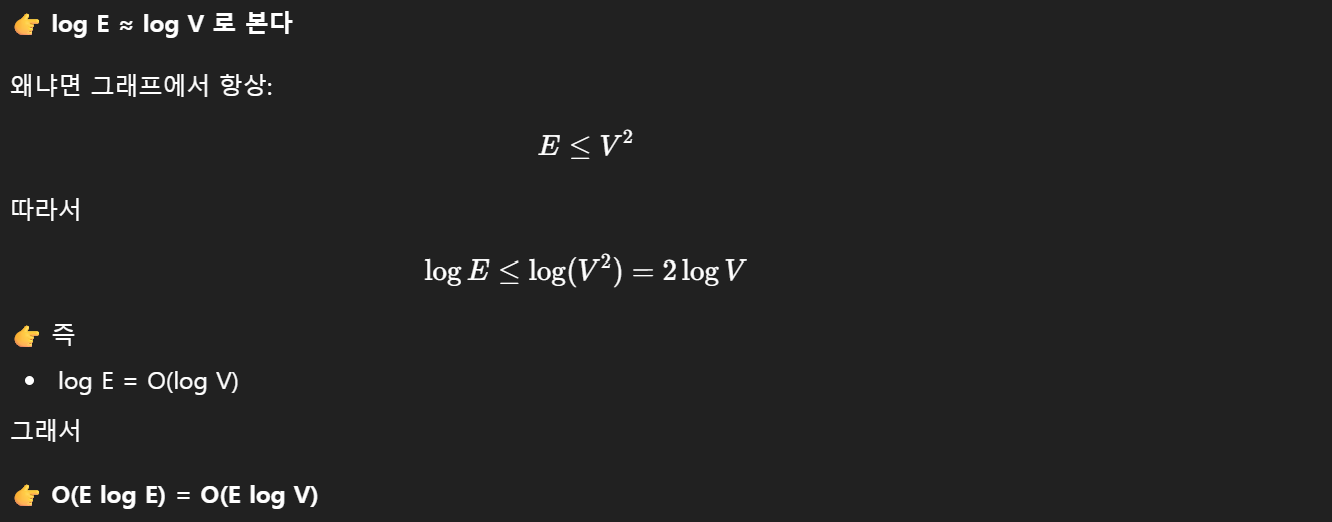

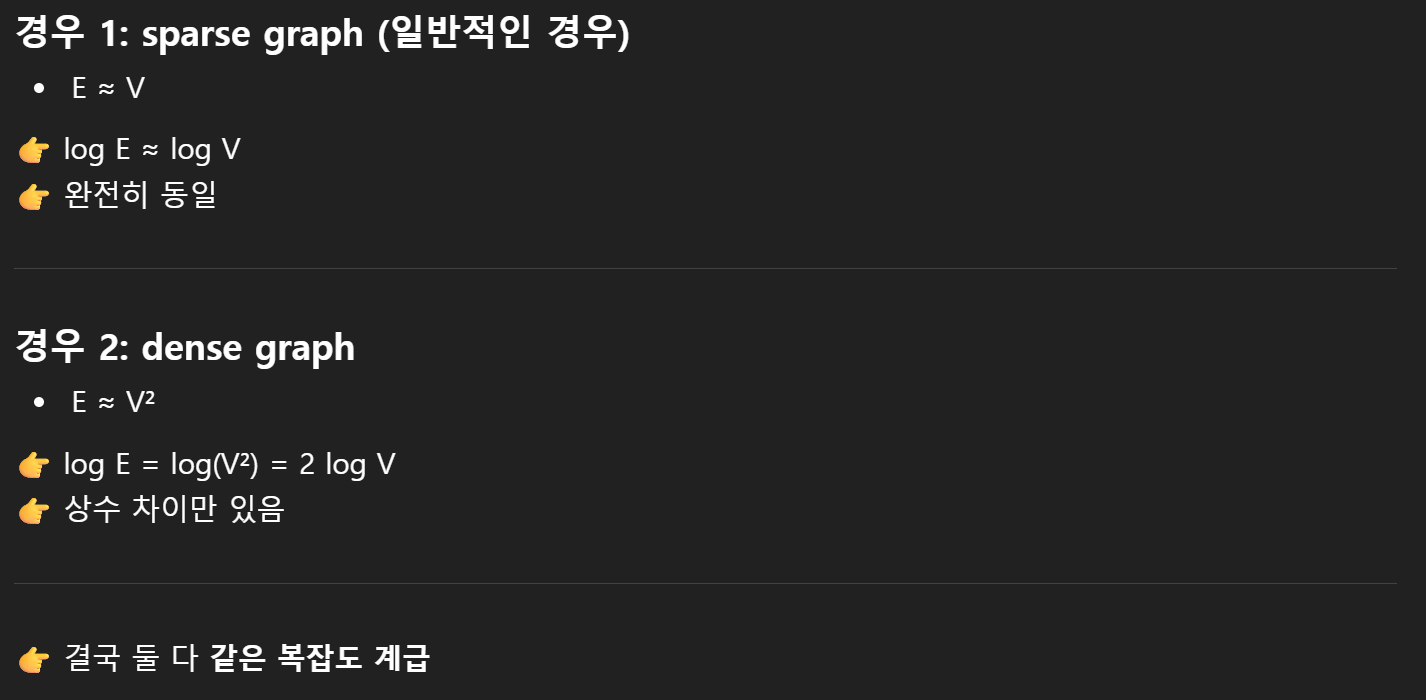

> 👉 **“heap 다익스트라에서는, 유효한 값으로 pop되는 순간이 visited와 동일한 의미이기 때문에 별도의 visited 배열이 필요 없다.”**

In [ ]:
import heapq # edge를 저장할 priority queue
INF = int(1e9)

# node 개수, edge 개수
node, edge = map(int, input().split())
# 시작 노드 번호
start = int(input())
# 각 노드와 연결된 노드에 대한 정보 담는 리스트 (graph)
graph = [[] for i in range(node + 1)]
# 최단 거리 테이블을 모두 무한으로 초기화
minimum_distance = [INF] * (node + 1)

# 간선 정보 입력 받기
for _ in range(edge):
    # 시작 노드, 끝 노드, 비용
    start_node, end_node, cost = map(int, input().split())
    graph[start_node].append((end_node, cost))
    ### graph에는 end_node, cost 순서로 저장되어 있고 ###
    ### heap에는 cost, 도착 노드 순서로 삽입한다는 것에 주의 ###

def dijkstra(start):
    priority_q = []
    # (해당 노드까지의 최소 비용, 도착노드)
    heapq.heappush(priority_q, (0, start))
    minimum_distance[start] = 0
    while priority_q:
        distance, present_node = heapq.heappop(priority_q)
        # pop된 (distance, present_node)가 현재 minimum_distance[present_node]와 같다면(==),
        # 이 순간 present_node까지의 최단 거리는 확정된다.
        # present_node[present_node] < distance 라면, 이전에 이미 heap에서 pop이 되었던
        # 이력이 있는 node라는 것
        if minimum_distance[present_node] < distance:
            continue # == 이라면, continue 하지 않고,
            # 연결된 edge들로 distance update를 하고 heap에 넣는다.
        for next_node, cost_for_next_node in graph[present_node]:
            cost = distance + cost_for_next_node
            if cost < minimum_distance[i[0]]:
                distance[next_node] = cost
                heapq.heappush(priority_q, (cost, next_node))


dijkstra(start)

for i in range(1, node + 1):
    if distance[i] == INF:
        print("INFINITY")
    else:
        print(distance[i])

In [ ]:
# distance[present_node] == dist → 유효 → 처리
# distance[present_node] < dist  → heap에 추가될 때는 최소 거리였는데, pop이 된 시점에서는 이전에 더 짧은 거리의 경로가 발견되어 update된 시점인 것임

> ## **플로이드 워셜**

- 모든 지점에서 다른 모든 지점까지의 최단 경로를 모두 구해야하는 경우 사용
- 다만, 매번 방문하지 않은 노드 중에서 최단 거리를 갖는 노드를 찾아서 방문 후 최단 거리를 업데이트 하는 다익스트라 알고리즘과 달리, N 개의 노드에 대해 매번 O(N^2)의 연산을 통해 현재 노드를 거쳐 가는 모든 경로를 고려하기에 총 O(N^3)의 시간 복잡도를 가진다.
- 매 단계에서 현재 확인하고 있는 노드를 제외하고 N-1개의 노드 중에서 서로 다른 노드 (A,B)쌍을 선택한다. 이후 "A 노드 -> 해당 노드 -> B 노드"로 가는 비용을 확인한 뒤에 최단 거리를 갱신한다.

> A -> B로의 Distance = min ( A -> B로의 Distance, A -> K -> B 로의 Distance )

> **k가 바깥에 있지 않으면, 어떤 (start, end)는 필요한 중간 경로 정보가 아직 반영되지 않은 상태에서 갱신이 끝나버린다. 플로이드 워셜은 각 k 단계마다 모든 (start, end)를 ‘k까지의 중간 노드가 완전히 반영된 상태’에서 다시 평가해야 하므로, k를 가장 바깥에 둬야 한다.**

In [ ]:
INF = int(1e9)
# node 수, edge 수
node = int(input())
edge = int(input())
# A -> B로의 최소 비용을 저장하는 2차원 list 만들기
# 초기 비용은 무한대
graph = [[INF] * (node+1) for _ in range(node+1)]

for start in range(1,node+1):
    for end in range(1,node+1):
        if start == end:
            graph[start][end] = 0

for _ in range(edge):
    start, end, cost = map(int, input().split())
    graph[start][end] = cost

# dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])
# 중간 지점에 대한 for문이 가장 바깥에 위치해야
# 매번 반복마다, 모든 (start,end) case를 업데이트 가능
for mid in range(1,node+1):
    for start in range(1, node + 1):
        for end in range(1, node + 1):
            graph[start][end] = min(graph[start][end], graph[start][mid] + graph[mid][end])

for start in range(1, node+1):
    for end in range(1,node+1):
        if graph[start][end] == INF:
            print("INF", end = " ")
        else:
            print(graph[start][end],end = " ")
    print()


### 실전 문제 2. 미래 도시

- 모든 간선의 비용이 1이기에, 플로이드 워셜. 다익스트라, BFS로 모두 풀 수 있는 문제이다.

- 이떄, 다익스트라와 BFS의 경우에는 1 → K와 K → X에서의 최단 거리를 더한 값을 출력하면 된다.

In [ ]:
# 플로이드 워셜 버전 코드
node, edge = map(int,input().split())
final, meeting = map(int,input().split())

INF = int(1e9)
graph = [[INF] * (node + 1) for _ in range(node+1)]

for i in range(1,node+1):
    graph[i][i] = 0

for _ in range(edge):
    start, end = map(int,input().split())
    graph[start][end] = 1
    graph[end][start] = 1

for mid in range(1, node+1):
    for start in range(1, node + 1):
        for end in range(1, node + 1):
            graph[start][end] = min(graph[start][end], graph[start][mid] + graph[mid][end])

distance = graph[1][meeting] + graph[meeting][final]
if distance >= INF:
  print("-1")
else:
  print(distance)

In [ ]:
# 다익스트라 알고리즘 버전 코드
import heapq
node, edge = map(int,input().split())
final, meeting = map(int,input().split())
INF = int(1e9)
graph = [[] for _ in range(node+1)]
for _ in range(edge):
    start_node,end_node = map(int,input().split())
    # (도착 노드, 비용)
    graph[start_node].append((end_node, 1))
    graph[end_node].append((start_node, 1))

result_cost = 0
for start, end in [(1, meeting), (meeting, final)]:
    min_cost = [INF] * (node+1)

    def dijkstra(start):
        priority_q = []
        heapq.heappush(priority_q, (0, start))
        min_cost[start] = 0

        while priority_q:
            total_cost, present_node = heapq.heappop(priority_q)
            if total_cost > min_cost[present_node]:
                continue

            for future_node, future_add_cost in graph[present_node]:
                future_cost = total_cost + future_add_cost
                if future_cost < min_cost[future_node]:
                    min_cost[future_node] = future_cost
                    heapq.heappush(priority_q, (future_cost, future_node))

    dijkstra(start)
    result_cost += min_cost[end]

print(result_cost)


In [ ]:
# BFS 버전 코드
from collections import deque

node, edge = map(int, input().split())
final, meeting = map(int, input().split())

graph = [[] for _ in range(node+1)]
for _ in range(edge):
    start, end = map(int, input().split())
    graph[start].append(end)
    graph[end].append(start)

def bfs(start_node, target_node) -> int:
    if start_node == target_node:
        return 0
    queue = deque([(start_node, 0)])
    visited = [False] * (node+1)
    visited[start_node] = True
    while queue:
        present_node, present_cost = queue.popleft()

        for next_node in graph[present_node]:
            if not visited[next_node]:
                visited[next_node] = True
                queue.append((next_node, present_cost+1))
                if next_node == target_node:
                    return present_cost+1

    return int(1e9)

print(bfs(1,meeting) + bfs(meeting, final))

> BFS에서 tuple 형식으로 queue에 넣지 않고 distance 배열을 사용해서 구현하는 방법

In [1]:
from collections import deque

node, edge = map(int, input().split())
final, meeting = map(int, input().split())

graph = [[] for _ in range(node+1)]
for _ in range(edge):
    start, end = map(int, input().split())
    graph[start].append(end)
    graph[end].append(start)

def bfs(start_node, target_node) -> int:
    if start_node == target_node:
        return 0
    queue = deque([start_node])
    distance = [-1] * (node+1) # distance 배열의 값이 음수이면 방문 X
    distance[start_node] = 0
    while queue:
        present_node = queue.popleft()

        for next_node in graph[present_node]:
            if distance[next_node] < 0:
                # 다음 노드까지의 거리 : 현재 노드까지의 거리 + 1
                distance[next_node] = distance[present_node] + 1
                queue.append(next_node)
                if next_node == target_node:
                    return distance[next_node]

    return int(1e9)

print(bfs(1,meeting) + bfs(meeting, final))

2

### 실전 문제 3. 전보

In [ ]:
import heapq
node, edge, start_city = map(int, input().split())
INF = int(1e9)
minimum_cost = [INF] * (node+1)
graph = [[] for _ in range(node + 1)]
for _ in range(edge):
    start, end, cost = map(int, input().split())
    # 도착노드, 그때의 비용
    graph[start].append((end, cost))

def dijkstra(start):
    priority_q = []
    # (거리, 다음 노드)
    heapq.heappush(priority_q, (0,start))
    minimum_cost[start] = 0
    while priority_q:
        present_dist, present_node = heapq.heappop(priority_q)
        if present_dist > minimum_cost[present_node]:
            continue
        for next_node, next_dist in graph[present_node]:
            next_total_dist = minimum_cost[present_node] + next_dist
            if next_total_dist < minimum_cost[next_node]:
                minimum_cost[next_node] = next_total_dist
                # (거리, 다음 노드)
                heapq.heappush(priority_q, (next_total_dist, next_node))

dijkstra(start_city)
final_list = [ city for city in minimum_cost if 0 < city < INF]
if len(final_list) == 0:
    print("0 0")
else:
    print(len(final_list), max(final_list))